In [8]:
# CELL 1: IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

os.makedirs('../results', exist_ok=True)
os.makedirs('../data', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print(' Libraries imported!')
print('Libraries: numpy, pandas, sklearn, imbalanced-learn')

 Libraries imported!
Libraries: numpy, pandas, sklearn, imbalanced-learn


In [9]:
#CELL 2: LOAD DATA

try:
    df = pd.read_csv('C:/Users/yajne/Desktop/CREDIT_CARD_FREAUD/data/creditcard.csv')
    print(' Full dataset loaded!')
except FileNotFoundError:
    df = pd.read_csv('../data/sample_creditcard.csv')
    print('  Sample dataset loaded.')

print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')
print(f'\nClass counts:')
print(df['Class'].value_counts())

 Full dataset loaded!
Shape: (284807, 31)
Fraud rate: 0.1727%

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


=== Step 1: Feature Engineering ===
  Original features: 30 (Time + V1-V28 + Amount)
  After engineering: 32 input features
  Added: Hour_sin, Hour_cos, Log_Amount
  Removed: Time (replaced by cyclical encoding)


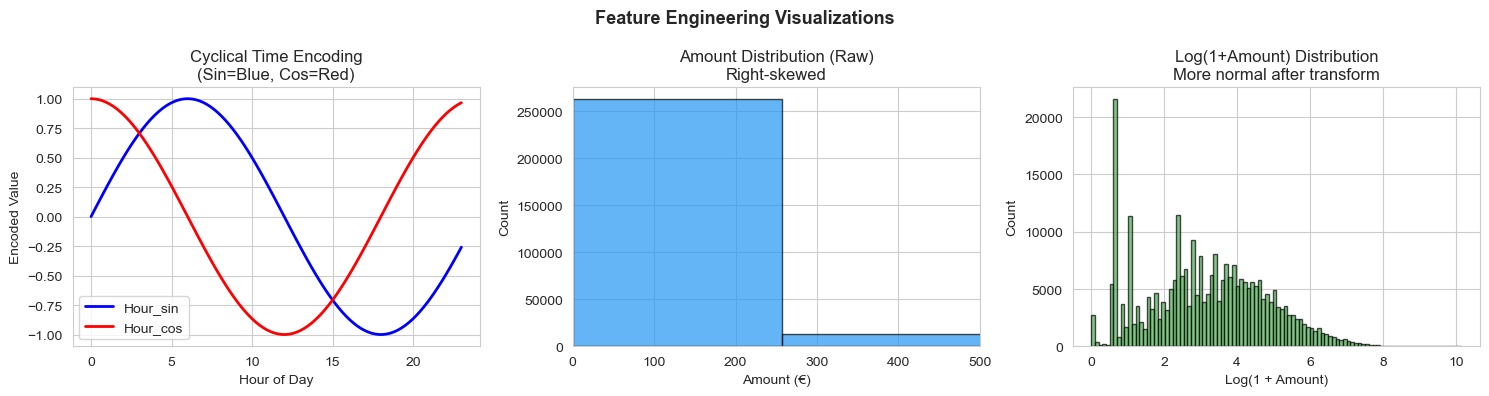


 Saved: results/feature_engineering.png


In [10]:
# CELL 3: FEATURE ENGINEERING

print('=== Step 1: Feature Engineering ===')
df_fe = df.copy()

# 1. TIME: Convert to hour of day using cyclical encoding
# Cyclical encoding preserves the circular nature of time
# (hour 23 is close to hour 0)
df_fe['Hour'] = (df_fe['Time'] / 3600) % 24
df_fe['Hour_sin'] = np.sin(2 * np.pi * df_fe['Hour'] / 24)
df_fe['Hour_cos'] = np.cos(2 * np.pi * df_fe['Hour'] / 24)

# 2. AMOUNT: Log-transform to reduce right skewness
# log1p(x) = log(1+x) handles Amount=0 cases
df_fe['Log_Amount'] = np.log1p(df_fe['Amount'])

# 3. DROP original Time (replaced by cyclical features)
# Keep Amount — we'll scale it separately
df_fe = df_fe.drop(['Time', 'Hour'], axis=1)

print(f'  Original features: 30 (Time + V1-V28 + Amount)')
print(f'  After engineering: {df_fe.shape[1]-1} input features')
print(f'  Added: Hour_sin, Hour_cos, Log_Amount')
print(f'  Removed: Time (replaced by cyclical encoding)')

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hours = np.linspace(0, 23, 100)
axes[0].plot(hours, np.sin(2*np.pi*hours/24), 'b-', linewidth=2)
axes[0].plot(hours, np.cos(2*np.pi*hours/24), 'r-', linewidth=2)
axes[0].set_title('Cyclical Time Encoding\n(Sin=Blue, Cos=Red)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Encoded Value')
axes[0].legend(['Hour_sin', 'Hour_cos'])

axes[1].hist(df_fe['Amount'], bins=100, color='#2196F3', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount Distribution (Raw)\nRight-skewed')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 500)

axes[2].hist(df_fe['Log_Amount'], bins=100, color='#4CAF50', alpha=0.7, edgecolor='black')
axes[2].set_title('Log(1+Amount) Distribution\nMore normal after transform')
axes[2].set_xlabel('Log(1 + Amount)')
axes[2].set_ylabel('Count')

plt.suptitle('Feature Engineering Visualizations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Saved: results/feature_engineering.png')

=== Step 2: Stratified Train/Val/Test Split ===
Feature matrix X: (284807, 32)
Target vector y:  (284807,)
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour_sin', 'Hour_cos', 'Log_Amount']

=== Split Summary ===
  Train       : 182,276 samples | Fraud=315 (0.173%) | Split=64.0%
  Validation  : 45,569 samples | Fraud=79 (0.173%) | Split=16.0%
  Test        : 56,962 samples | Fraud=98 (0.172%) | Split=20.0%


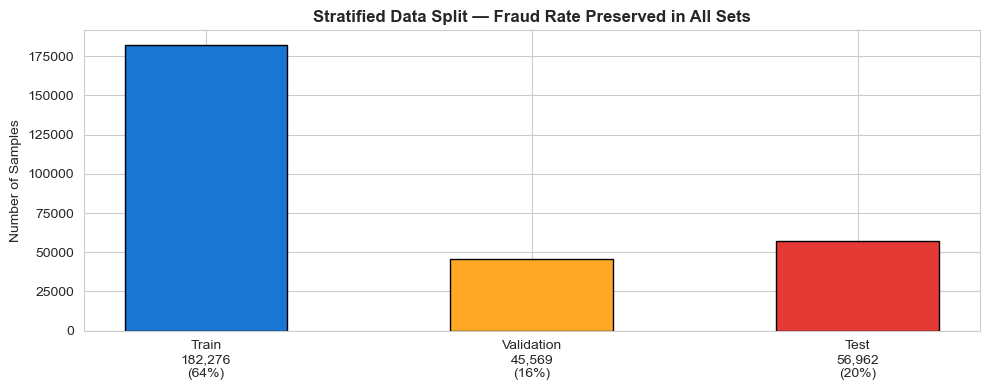


 Stratified split complete — fraud ratio preserved in all sets!


In [11]:
# CELL 4: STRATIFIED TRAIN/VAL/TEST SPLIT

print('=== Step 2: Stratified Train/Val/Test Split ===')

X = df_fe.drop('Class', axis=1)
y = df_fe['Class']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y:  {y.shape}')
print(f'Features: {list(X.columns)}')

# Step 1: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # ← Critical: maintains fraud ratio in each split
)

# Step 2: 80% train, 20% val (from trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

print('\n=== Split Summary ===')
for name, X_s, y_s in [('Train', X_train, y_train),
                        ('Validation', X_val, y_val),
                        ('Test', X_test, y_test)]:
    fraud_n = y_s.sum()
    print(f'  {name:12s}: {len(X_s):,} samples | '
          f'Fraud={fraud_n} ({y_s.mean()*100:.3f}%) | '
          f'Split={len(X_s)/len(X)*100:.1f}%')

# Visualize split
fig, ax = plt.subplots(figsize=(10, 4))
split_sizes = [len(X_train), len(X_val), len(X_test)]
split_labels = [f'Train\n{len(X_train):,}\n({len(X_train)/len(X)*100:.0f}%)',
                f'Validation\n{len(X_val):,}\n({len(X_val)/len(X)*100:.0f}%)',
                f'Test\n{len(X_test):,}\n({len(X_test)/len(X)*100:.0f}%)']
bars = ax.bar(split_labels, split_sizes,
              color=['#1976D2', '#FFA726', '#E53935'],
              edgecolor='black', width=0.5)
ax.set_title('Stratified Data Split — Fraud Rate Preserved in All Sets',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('../results/data_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Stratified split complete — fraud ratio preserved in all sets!')

=== Step 3: Feature Scaling ===
  IMPORTANT: Scaler fit ONLY on training data!
   Prevents data leakage from test/val into training.

Columns to scale: ['Amount', 'Log_Amount', 'Hour_sin', 'Hour_cos']
V1-V28: Already PCA-transformed → no additional scaling

=== Scaling Verification (Train set) ===
  Amount         : mean=-0.000000, std=1.000003 →  Correct
  Log_Amount     : mean=-0.000000, std=1.000003 →  Correct
  Hour_sin       : mean=+0.000000, std=1.000003 →  Correct
  Hour_cos       : mean=-0.000000, std=1.000003 →  Correct


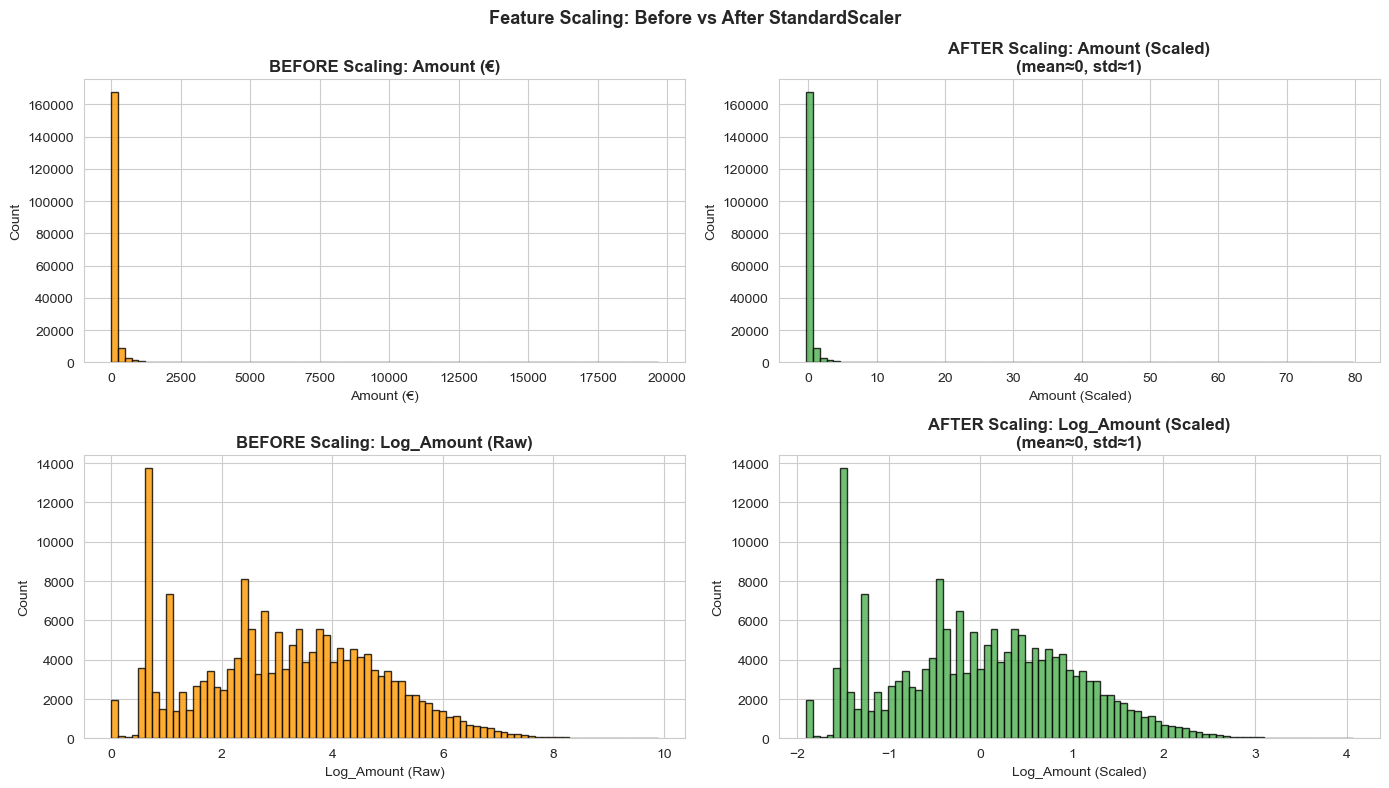


 Scaler saved to results/scaler.pkl (for deployment use)


In [12]:
# CELL 5: FEATURE SCALING

print('=== Step 3: Feature Scaling ===')
print('  IMPORTANT: Scaler fit ONLY on training data!')
print('   Prevents data leakage from test/val into training.\n')

# Only scale Amount and Log_Amount (V1-V28 are already PCA-scaled)
cols_to_scale = ['Amount', 'Log_Amount', 'Hour_sin', 'Hour_cos']
print(f'Columns to scale: {cols_to_scale}')
print(f'V1-V28: Already PCA-transformed → no additional scaling')

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

# Verify scaling
print('\n=== Scaling Verification (Train set) ===')
for col in cols_to_scale:
    mean = X_train_scaled[col].mean()
    std  = X_train_scaled[col].std()
    print(f'  {col:15s}: mean={mean:+.6f}, std={std:.6f} '
          f'→ {" Correct" if abs(mean) < 0.01 and abs(std-1) < 0.01 else "  Check"}')

# Before/After scaling visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
scale_pairs = [
    (X_train['Amount'], X_train_scaled['Amount'], 'Amount (€)', 'Amount (Scaled)'),
    (X_train['Log_Amount'], X_train_scaled['Log_Amount'], 'Log_Amount (Raw)', 'Log_Amount (Scaled)'),
]

for row, (before, after, label_b, label_a) in enumerate(scale_pairs):
    axes[row, 0].hist(before, bins=80, color='#FF9800', alpha=0.8, edgecolor='black')
    axes[row, 0].set_title(f'BEFORE Scaling: {label_b}', fontweight='bold')
    axes[row, 0].set_xlabel(label_b)
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(after, bins=80, color='#4CAF50', alpha=0.8, edgecolor='black')
    axes[row, 1].set_title(f'AFTER Scaling: {label_a}\n(mean≈0, std≈1)', fontweight='bold')
    axes[row, 1].set_xlabel(label_a)
    axes[row, 1].set_ylabel('Count')

plt.suptitle('Feature Scaling: Before vs After StandardScaler',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save scaler for deployment
joblib.dump(scaler, '../results/scaler.pkl')
print('\n Scaler saved to results/scaler.pkl (for deployment use)')

In [15]:
# CELL 6: SMOTE EXPLANATION + VISUALIZATION

print('=== SMOTE: How It Works ===')
print('''
SMOTE (Synthetic Minority Oversampling Technique):

  Problem: Fraud = 0.17% → Models ignore minority class
  
  Solution: Create SYNTHETIC fraud examples by:
  1. Pick a fraud transaction (minority sample)
  2. Find its K nearest fraud neighbors
  3. Create a new point BETWEEN the sample and a neighbor
  4. Repeat until desired balance is achieved

  Rules:
   Apply ONLY to training data
   NEVER apply to validation or test sets
   This prevents data leakage and overly optimistic results
  
  We use sampling_strategy=0.1 → Fraud becomes 10% of total
  (A balance between enough signal and not too artificial)
''')

=== SMOTE: How It Works ===

SMOTE (Synthetic Minority Oversampling Technique):

  Problem: Fraud = 0.17% → Models ignore minority class

  Solution: Create SYNTHETIC fraud examples by:
  1. Pick a fraud transaction (minority sample)
  2. Find its K nearest fraud neighbors
  3. Create a new point BETWEEN the sample and a neighbor
  4. Repeat until desired balance is achieved

  Rules:
   Apply ONLY to training data
   NEVER apply to validation or test sets
   This prevents data leakage and overly optimistic results

  We use sampling_strategy=0.1 → Fraud becomes 10% of total
  (A balance between enough signal and not too artificial)



=== Step 4: Applying SMOTE ===
BEFORE SMOTE: Counter({0: 181961, 1: 315})
  Fraud rate: 0.173%

AFTER SMOTE:  Counter({0: 181961, 1: 18196})
  Fraud rate: 9.1%
  New synthetic fraud samples: 17,881
  Total training samples: 200,157

Val and Test remain untouched (real-world distribution preserved)


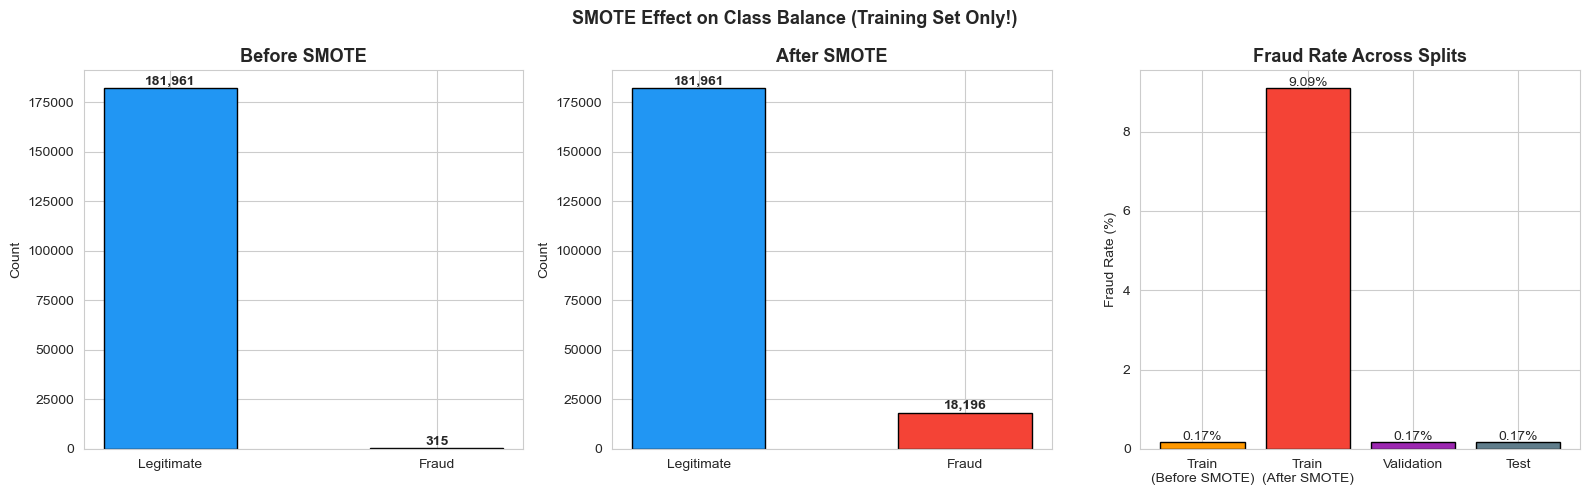

In [18]:
# CELL 7: APPLY SMOTE

from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

print('=== Step 4: Applying SMOTE ===')

# Check class distribution before SMOTE
before_counter = Counter(y_train)
print(f'BEFORE SMOTE: {before_counter}')
print(f'  Fraud rate: {y_train.mean()*100:.3f}%')

# Apply SMOTE ONLY on training data
smote = SMOTE(
    sampling_strategy=0.1,  # Fraud = 10% of legitimate
    k_neighbors=5,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution after SMOTE
after_counter = Counter(y_train_res)
print(f'\nAFTER SMOTE:  {after_counter}')
print(f'  Fraud rate: {y_train_res.mean()*100:.1f}%')
print(f'  New synthetic fraud samples: {after_counter[1] - before_counter[1]:,}')
print(f'  Total training samples: {len(X_train_res):,}')

print('\nVal and Test remain untouched (real-world distribution preserved)')

# ==============================
# Visualization
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2196F3', '#F44336']

# Before & After SMOTE
for ax, (counts, title) in zip(axes[:2], [
    (before_counter, 'Before SMOTE'),
    (after_counter, 'After SMOTE')
]):
    vals = [counts[0], counts[1]]
    bars = ax.bar(['Legitimate', 'Fraud'], vals,
                  color=colors, edgecolor='black', width=0.5)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,}',
                ha='center', fontweight='bold')

# Fraud rate comparison across splits
rates = [
    y_train.mean()*100,
    y_train_res.mean()*100,
    y_val.mean()*100,
    y_test.mean()*100
]

split_names = [
    'Train\n(Before SMOTE)',
    'Train\n(After SMOTE)',
    'Validation',
    'Test'
]

bar_colors = ['#FF9800', '#F44336', '#9C27B0', '#607D8B']

axes[2].bar(split_names, rates,
            color=bar_colors, edgecolor='black')

axes[2].set_title('Fraud Rate Across Splits',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Fraud Rate (%)')

for i, v in enumerate(rates):
    axes[2].text(i, v + 0.05,
                 f'{v:.2f}%',
                 ha='center', fontsize=10)

plt.suptitle('SMOTE Effect on Class Balance (Training Set Only!)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/smote_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()

=== SMOTE Quality Check ===
Verifying synthetic samples look realistic...


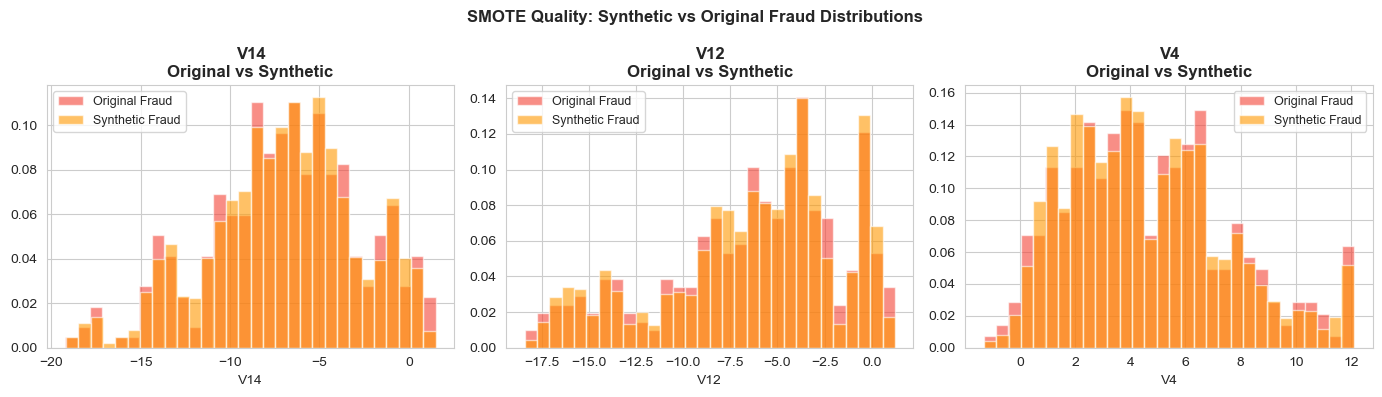

 Synthetic samples follow similar distribution to originals!


In [19]:
# CELL 8: VERIFY SMOTE QUALITY

print('=== SMOTE Quality Check ===')
print('Verifying synthetic samples look realistic...')

# Compare original fraud vs synthetic fraud feature distributions
original_fraud_idx = np.where(y_train == 1)[0]
original_fraud_X = X_train_scaled.values[original_fraud_idx]

# Get all fraud from resampled (includes synthetic)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
all_fraud_idx = np.where(y_train_res_arr == 1)[0]
all_fraud_X = X_train_res.values[all_fraud_idx] if hasattr(X_train_res, 'values') else X_train_res[all_fraud_idx]

# Synthetic only
synthetic_only = all_fraud_X[len(original_fraud_idx):]

# Compare distributions for top 3 features
feature_names = list(X_train_scaled.columns)
top3 = ['V14', 'V12', 'V4']  # Common top features
top3_idx = [feature_names.index(f) for f in top3 if f in feature_names]

fig, axes = plt.subplots(1, len(top3_idx), figsize=(14, 4))

for i, feat_idx in enumerate(top3_idx):
    feat_name = feature_names[feat_idx]
    axes[i].hist(original_fraud_X[:, feat_idx], bins=30, alpha=0.6,
                 color='#F44336', label='Original Fraud', density=True)
    if len(synthetic_only) > 0:
        axes[i].hist(synthetic_only[:, feat_idx], bins=30, alpha=0.6,
                     color='#FF9800', label='Synthetic Fraud', density=True)
    axes[i].set_title(f'{feat_name}\nOriginal vs Synthetic', fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel(feat_name)

plt.suptitle('SMOTE Quality: Synthetic vs Original Fraud Distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/smote_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Synthetic samples follow similar distribution to originals!')

In [20]:
# CELL 9: SAVE ALL PROCESSED DATA

print('=== Saving Processed Data ===')

# Convert to numpy arrays
X_train_arr = X_train_res.values if hasattr(X_train_res, 'values') else X_train_res
y_train_arr = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
X_val_arr   = X_val_scaled.values
y_val_arr   = y_val.values
X_test_arr  = X_test_scaled.values
y_test_arr  = y_test.values

# Save as numpy arrays
np.save('../data/X_train.npy', X_train_arr)
np.save('../data/y_train.npy', y_train_arr)
np.save('../data/X_val.npy',   X_val_arr)
np.save('../data/y_val.npy',   y_val_arr)
np.save('../data/X_test.npy',  X_test_arr)
np.save('../data/y_test.npy',  y_test_arr)

# Save feature names
feature_names = list(X_train_scaled.columns)
pd.DataFrame({'feature': feature_names}).to_csv('../data/feature_names.csv', index=False)

# Save scaler
joblib.dump(scaler, '../results/scaler.pkl')

print('Files saved:')
saved_files = [
    ('data/X_train.npy', X_train_arr.shape, 'Training features (SMOTE applied)'),
    ('data/y_train.npy', y_train_arr.shape, 'Training labels (SMOTE applied)'),
    ('data/X_val.npy',   X_val_arr.shape,   'Validation features'),
    ('data/y_val.npy',   y_val_arr.shape,   'Validation labels'),
    ('data/X_test.npy',  X_test_arr.shape,  'Test features'),
    ('data/y_test.npy',  y_test_arr.shape,  'Test labels'),
    ('data/feature_names.csv', f'({len(feature_names)} features)', 'Feature name list'),
    ('results/scaler.pkl', 'joblib', 'StandardScaler for deployment'),
]
for fname, shape, desc in saved_files:
    print(f'   {fname:30s} {str(shape):20s} → {desc}')

=== Saving Processed Data ===
Files saved:
   data/X_train.npy               (200157, 32)         → Training features (SMOTE applied)
   data/y_train.npy               (200157,)            → Training labels (SMOTE applied)
   data/X_val.npy                 (45569, 32)          → Validation features
   data/y_val.npy                 (45569,)             → Validation labels
   data/X_test.npy                (56962, 32)          → Test features
   data/y_test.npy                (56962,)             → Test labels
   data/feature_names.csv         (32 features)        → Feature name list
   results/scaler.pkl             joblib               → StandardScaler for deployment


In [21]:
# CELL 10: PREPROCESSING COMPLETE SUMMARY

print('=' * 65)
print('        PREPROCESSING COMPLETE SUMMARY')
print('=' * 65)
print(f'''
STEPS COMPLETED:

  1️  FEATURE ENGINEERING:
      Time → Hour_sin + Hour_cos (cyclical encoding)
      Amount → Log_Amount (reduces right skew)
      Dropped raw Time column
      V1–V28 kept as-is (already PCA-transformed)
     Final features: {len(feature_names)}

  2️  STRATIFIED SPLIT (preserves fraud rate):
      Train:      {X_train_arr.shape[0]:,} samples (64%)
      Validation: {X_val_arr.shape[0]:,} samples (16%)
      Test:       {X_test_arr.shape[0]:,} samples (20%)
      Fraud rate preserved in ALL splits

  3  STANDARD SCALING:
      Fit ONLY on training data (no leakage!)
      Columns scaled: Amount, Log_Amount, Hour_sin, Hour_cos
      Scaler saved for production deployment

  4️  SMOTE OVERSAMPLING (training only!):
      Fraud: 0.17% → 10% of training set
      k_neighbors=5, strategy=0.1
      Val and Test untouched (real-world distribution)

DATA ANTI-LEAKAGE SUMMARY:
   Scaler fit ONLY on train
   SMOTE applied ONLY to train
   Val/Test simulate real deployment conditions

  NEXT STEP: Run 03_model_training.ipynb
''')
print('=' * 65)

        PREPROCESSING COMPLETE SUMMARY

STEPS COMPLETED:

  1️  FEATURE ENGINEERING:
      Time → Hour_sin + Hour_cos (cyclical encoding)
      Amount → Log_Amount (reduces right skew)
      Dropped raw Time column
      V1–V28 kept as-is (already PCA-transformed)
     Final features: 32

  2️  STRATIFIED SPLIT (preserves fraud rate):
      Train:      200,157 samples (64%)
      Validation: 45,569 samples (16%)
      Test:       56,962 samples (20%)
      Fraud rate preserved in ALL splits

  3  STANDARD SCALING:
      Fit ONLY on training data (no leakage!)
      Columns scaled: Amount, Log_Amount, Hour_sin, Hour_cos
      Scaler saved for production deployment

  4️  SMOTE OVERSAMPLING (training only!):
      Fraud: 0.17% → 10% of training set
      k_neighbors=5, strategy=0.1
      Val and Test untouched (real-world distribution)

DATA ANTI-LEAKAGE SUMMARY:
   Scaler fit ONLY on train
   SMOTE applied ONLY to train
   Val/Test simulate real deployment conditions

  NEXT STEP: Run 0